In [77]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [78]:
!pip install kagglehub

In [79]:
import kagglehub

path = kagglehub.dataset_download(
    "ruchi798/housing-prices-in-metropolitan-areas-of-india"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'housing-prices-in-metropolitan-areas-of-india' dataset.
Path to dataset files: /kaggle/input/housing-prices-in-metropolitan-areas-of-india


In [80]:
import os

os.listdir(path)

['Delhi.csv',
 'Kolkata.csv',
 'Hyderabad.csv',
 'Bangalore.csv',
 'Mumbai.csv',
 'Chennai.csv']

In [81]:
import pandas as pd

bangalore = pd.read_csv(f"{path}/Bangalore.csv")
chennai = pd.read_csv(f"{path}/Chennai.csv")
delhi = pd.read_csv(f"{path}/Delhi.csv")
hyderabad = pd.read_csv(f"{path}/Hyderabad.csv")
kolkata = pd.read_csv(f"{path}/Kolkata.csv")
mumbai = pd.read_csv(f"{path}/Mumbai.csv")

In [82]:
bangalore.head()

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
0,30000000,3340,JP Nagar Phase 1,4,0,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
1,7888000,1045,Dasarahalli on Tumkur Road,2,0,0,1,1,1,1,...,1,0,1,0,0,0,0,0,0,0
2,4866000,1179,Kannur on Thanisandra Main Road,2,0,0,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
3,8358000,1675,Doddanekundi,3,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,6845000,1670,Kengeri,3,0,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0


In [83]:
bangalore["city"] = "Bangalore"
chennai["city"] = "Chennai"
delhi["city"] = "Delhi"
hyderabad["city"] = "Hyderabad"
kolkata["city"] = "Kolkata"
mumbai["city"] = "Mumbai"

In [84]:
df = pd.concat(
    [bangalore, chennai, delhi, hyderabad, kolkata, mumbai],
    ignore_index=True
)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32963 entries, 0 to 32962
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Price                32963 non-null  int64 
 1   Area                 32963 non-null  int64 
 2   Location             32963 non-null  object
 3   No. of Bedrooms      32963 non-null  int64 
 4   Resale               32963 non-null  int64 
 5   MaintenanceStaff     32963 non-null  int64 
 6   Gymnasium            32963 non-null  int64 
 7   SwimmingPool         32963 non-null  int64 
 8   LandscapedGardens    32963 non-null  int64 
 9   JoggingTrack         32963 non-null  int64 
 10  RainWaterHarvesting  32963 non-null  int64 
 11  IndoorGames          32963 non-null  int64 
 12  ShoppingMall         32963 non-null  int64 
 13  Intercom             32963 non-null  int64 
 14  SportsFacility       32963 non-null  int64 
 15  ATM                  32963 non-null  int64 
 16  Club

In [86]:
df.columns = df.columns.str.replace(" ", "_")

In [87]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Location"] = le.fit_transform(df["Location"])
df["city"] = le.fit_transform(df["city"])

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32963 entries, 0 to 32962
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Price                32963 non-null  int64
 1   Area                 32963 non-null  int64
 2   Location             32963 non-null  int64
 3   No._of_Bedrooms      32963 non-null  int64
 4   Resale               32963 non-null  int64
 5   MaintenanceStaff     32963 non-null  int64
 6   Gymnasium            32963 non-null  int64
 7   SwimmingPool         32963 non-null  int64
 8   LandscapedGardens    32963 non-null  int64
 9   JoggingTrack         32963 non-null  int64
 10  RainWaterHarvesting  32963 non-null  int64
 11  IndoorGames          32963 non-null  int64
 12  ShoppingMall         32963 non-null  int64
 13  Intercom             32963 non-null  int64
 14  SportsFacility       32963 non-null  int64
 15  ATM                  32963 non-null  int64
 16  ClubHouse            3

In [89]:
import numpy as np

df["Price"] = np.log1p(df["Price"])

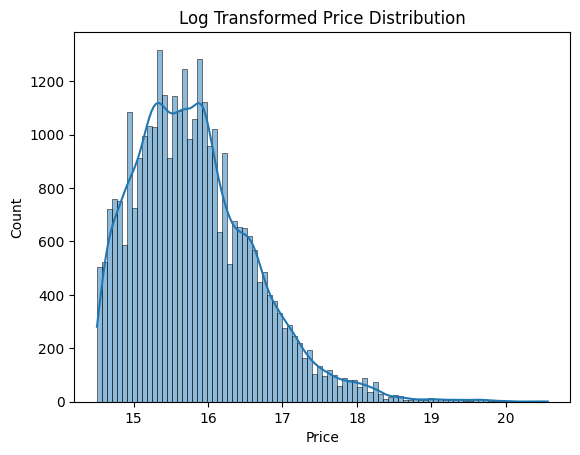

In [90]:
sns.histplot(df["Price"], kde=True)
plt.title("Log Transformed Price Distribution")
plt.show()

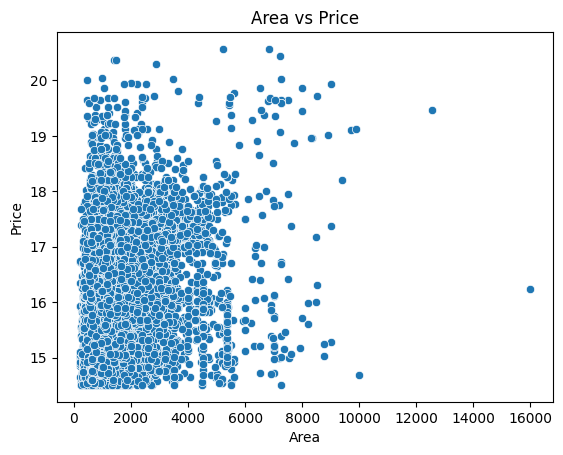

In [91]:
sns.scatterplot(x=df["Area"], y=df["Price"])
plt.title("Area vs Price")
plt.show()

In [93]:
df.skew().sort_values(ascending=False).head(10)

,0
Area,3.500759
Price,0.911153
Resale,0.488371
No._of_Bedrooms,0.354367
Location,0.013059
city,-0.100746
Wifi,-0.842051
Wardrobe,-0.842124
GolfCourse,-0.842160
WashingMachine,-0.843243


In [94]:
corr = df.corr()["Price"].sort_values(ascending=False)
corr.head(15)

,Price
Price,1.000000
Area,0.353775
No._of_Bedrooms,0.233233
Resale,0.079486
city,0.062564
Location,0.004451
Children'splayarea,-0.004915
PowerBackup,-0.005445
ClubHouse,-0.005576
Gymnasium,-0.005929


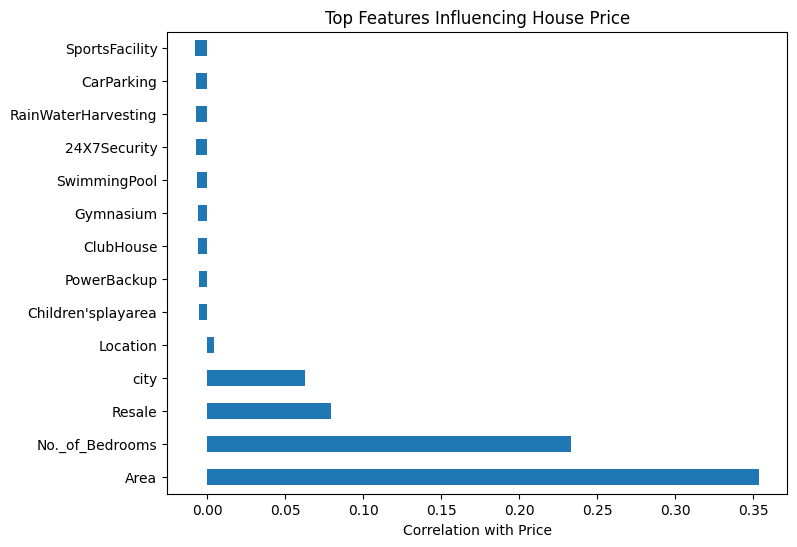

In [95]:
top_features = corr[1:15]

plt.figure(figsize=(8,6))
top_features.plot(kind="barh")

plt.title("Top Features Influencing House Price")
plt.xlabel("Correlation with Price")

plt.show()

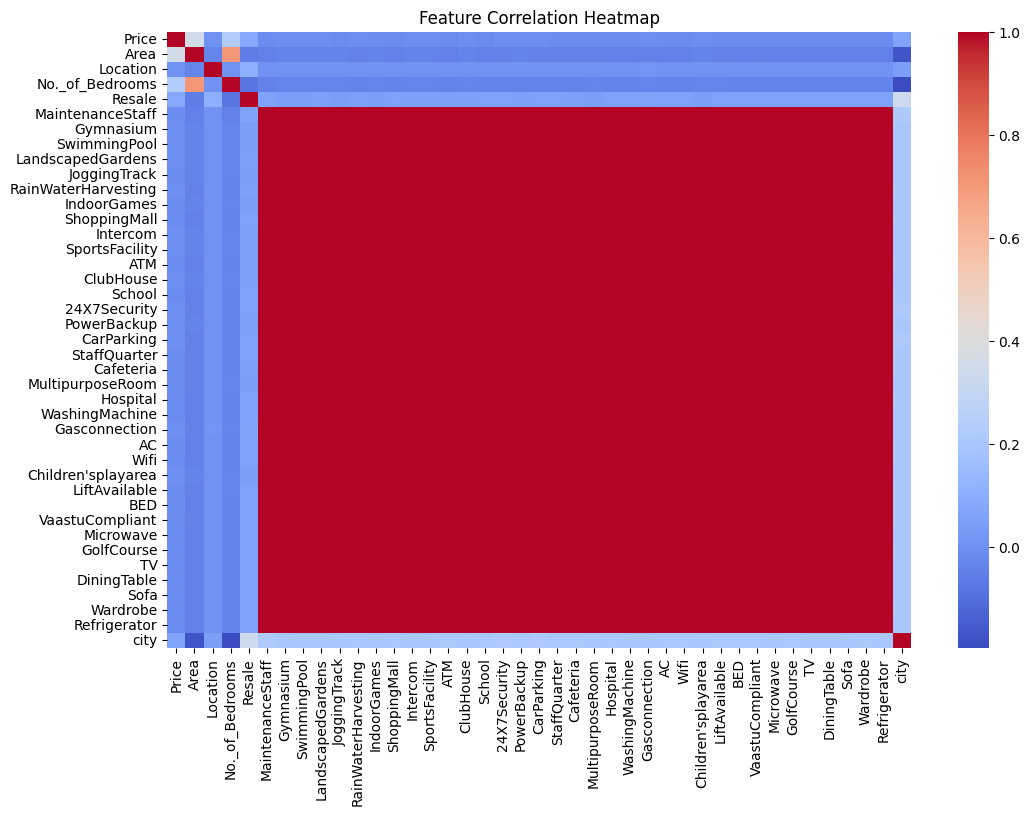

In [96]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

In [97]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [99]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [100]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [101]:
from xgboost import XGBRegressor

xgb = XGBRegressor()

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [102]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [103]:
def evaluate(y_true, pred):

    mae = mean_absolute_error(y_true, pred)
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    r2 = r2_score(y_true, pred)

    return mae, rmse, r2

In [104]:
lr_results = evaluate(y_test, lr_pred)
rf_results = evaluate(y_test, rf_pred)
xgb_results = evaluate(y_test, xgb_pred)

In [105]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [lr_results[0], rf_results[0], xgb_results[0]],
    "RMSE": [lr_results[1], rf_results[1], xgb_results[1]],
    "R2 Score": [lr_results[2], rf_results[2], xgb_results[2]]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.561148,0.744699,0.176758
1,Random Forest,0.425739,0.659587,0.354183
2,XGBoost,0.422175,0.630822,0.409284


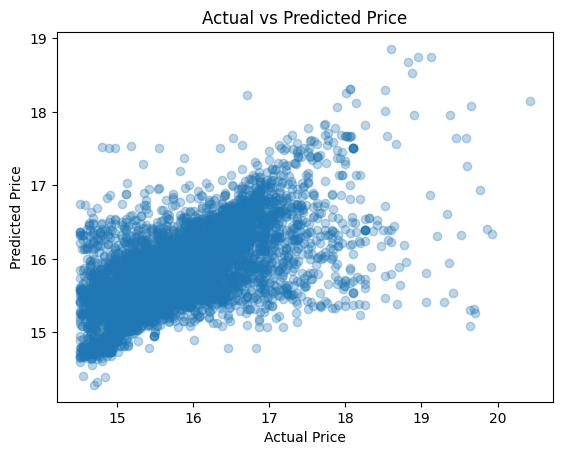

In [107]:
plt.scatter(y_test, xgb_pred, alpha=0.3)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

In [108]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor()

param_rf = {

    "n_estimators": [100,200,300,400],
    "max_depth": [10,15,20,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": ["sqrt","log2"]

}

rf_search = RandomizedSearchCV(

    rf,
    param_distributions=param_rf,
    n_iter=20,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42

)

rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_

rf_pred_tuned = rf_best.predict(X_test)

In [109]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor()

param_xgb = {

    "n_estimators": [100,200,300],
    "max_depth": [3,5,7,10],
    "learning_rate": [0.01,0.05,0.1],
    "subsample": [0.7,0.8,1],
    "colsample_bytree": [0.7,0.8,1]

}

xgb_search = RandomizedSearchCV(

    xgb,
    param_distributions=param_xgb,
    n_iter=20,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42

)

xgb_search.fit(X_train, y_train)

xgb_best = xgb_search.best_estimator_

xgb_pred_tuned = xgb_best.predict(X_test)

In [110]:
lr_results = evaluate(y_test, lr_pred)

rf_results_tuned = evaluate(y_test, rf_pred_tuned)

xgb_results_tuned = evaluate(y_test, xgb_pred_tuned)

In [111]:
results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest (Tuned)",
        "XGBoost (Tuned)"
    ],

    "MAE": [
        lr_results[0],
        rf_results_tuned[0],
        xgb_results_tuned[0]
    ],

    "RMSE": [
        lr_results[1],
        rf_results_tuned[1],
        xgb_results_tuned[1]
    ],

    "R2 Score": [
        lr_results[2],
        rf_results_tuned[2],
        xgb_results_tuned[2]
    ]

})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.561148,0.744699,0.176758
1,Random Forest (Tuned),0.426746,0.628966,0.412755
2,XGBoost (Tuned),0.424898,0.627373,0.415725


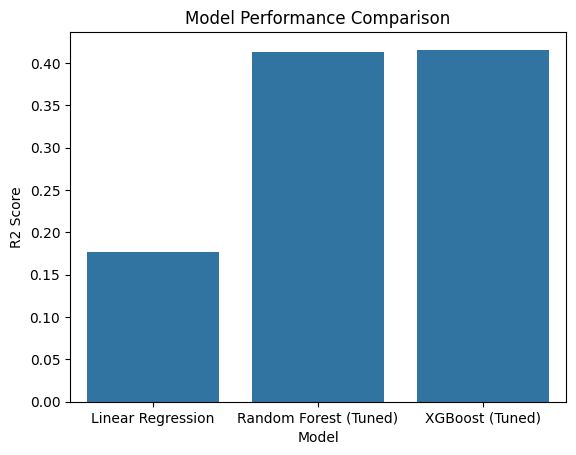

In [112]:
sns.barplot(x="Model", y="R2 Score", data=results)

plt.title("Model Performance Comparison")

plt.show()

In [113]:
best_model = results.sort_values(
    by="R2 Score",
    ascending=False
)

best_model

,Model,MAE,RMSE,R2 Score
2,XGBoost (Tuned),0.424898,0.627373,0.415725
1,Random Forest (Tuned),0.426746,0.628966,0.412755
0,Linear Regression,0.561148,0.744699,0.176758


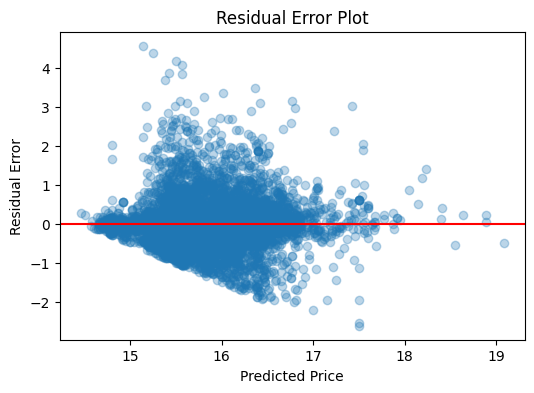

In [114]:
residuals = y_test - xgb_pred_tuned

plt.figure(figsize=(6,4))

plt.scatter(xgb_pred_tuned, residuals, alpha=0.3)

plt.axhline(0, color="red")

plt.xlabel("Predicted Price")
plt.ylabel("Residual Error")

plt.title("Residual Error Plot")

plt.show()

In [115]:
import pickle

pickle.dump(xgb_best, open("house_price_model.pkl","wb"))

In [116]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [117]:
import os

os.makedirs("/content/drive/MyDrive/HCL_Hackathon", exist_ok=True)

In [118]:
project_path = "/content/drive/MyDrive/HCL_Hackathon"

In [119]:
import pickle

pickle.dump(
    xgb_best,
    open("/content/drive/MyDrive/HCL_Hackathon/house_price_model.pkl", "wb")
)

In [120]:
df.to_csv(
"/content/drive/MyDrive/HCL_Hackathon/cleaned_dataset.csv",
index=False
)

In [121]:
results.to_csv(
"/content/drive/MyDrive/HCL_Hackathon/model_results.csv",
index=False
)

In [123]:
import json

with open(
"/content/drive/MyDrive/HCL_Hackathon/xgb_best_params.json",
"w"
) as f:

    json.dump(xgb_search.best_params_, f)

In [124]:
feature_importance.to_csv(
"/content/drive/MyDrive/HCL_Hackathon/feature_importance.csv"
)